# Проект: Определение фейковых новостей (Fake News Detection)

**Автор:** Бородин Святослав Михайлович <BR>
**Ссылка на репозиторий:** [Github](https://github.com/GrosBoy/Project-Fake-n-Real-News)<BR>
**Датасет:** [Kaggle Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) <BR>
**Цель проекта:** Разработать автоматизированную систему или алгоритм, способный с высокой точностью отличать достоверную информацию от преднамеренно ложной, вводящей в заблуждение или непроверенной (фейковой) в текстовом контенте, маскирующемся под новости.

### 1.1. Постановка задачи
В современном мире сложно отличить правдивую новость от ложной. Цель проекта — разработать автоматизированную систему (алгоритм), способную с высокой точностью классифицировать текстовый контент как "Real" (настоящий) или "Fake" (фейковый).

**Метрики качества:**
* Accuracy (основная метрика, цель > 85%)
* Precision, Recall, F1-score
* Confusion Matrix

### 1.2. Используемые библиотеки

In [21]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub # Для загрузки датасета

# NLP и Лингвистика
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Машинное обучение (Baseline)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Глубокое обучение (Deep Learning - LSTM)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Загрузка ресурсов NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Настройка стиля графиков
sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 2. Загрузка и первичный осмотр данных
Загружаем датасет напрямую из Kaggle и объединяем два файла (Fake.csv и True.csv) в один датафрейм, добавляя метки классов.

In [22]:
# Скачивание датасета
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
DATA_DIR = os.path.join(path, "")

print("Dataset folder:", DATA_DIR)

# Чтение файлов
true_df = pd.read_csv(os.path.join(DATA_DIR, 'True.csv'))
fake_df = pd.read_csv(os.path.join(DATA_DIR, 'Fake.csv'))

# Создание меток классов: 1 = Real, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

# Объединение в один датасет
data = pd.concat([true_df, fake_df], ignore_index=True)

# Перемешивание данных (Shuffle), чтобы классы не шли подряд
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Объединяем заголовок и текст для полноты информации
data['text_combined'] = data['title'] + " " + data['text']

print(f"Размер датасета: {data.shape}")
display(data.head())

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset folder: /kaggle/input/fake-and-real-news-dataset/
Размер датасета: (44898, 6)


,title,text,subject,date,label,text_combined
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0,BREAKING: GOP Chairman Grassley Has Had Enoug...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0,Failed GOP Candidates Remembered In Hilarious...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0,Mike Pence’s New DC Neighbors Are HILARIOUSLY...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0,AZ RANCHERS Living On US-Mexico Border Destroy...


### 3. Exploratory Data Analysis (EDA)
Проверим баланс классов, чтобы убедиться, что модель не будет переобучаться на один из них.

Пропуски в данных:
 title            0
text             0
subject          0
date             0
label            0
text_combined    0
dtype: int64


/tmp/ipython-input-3481171710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='viridis')


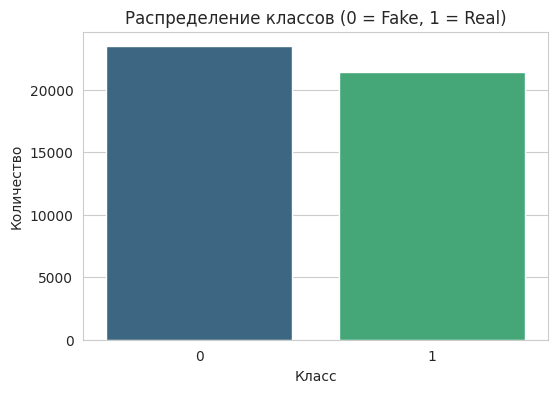

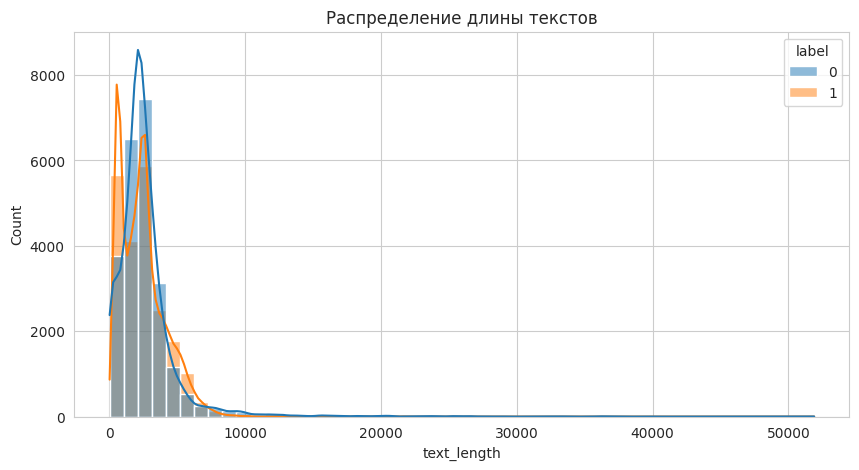

In [23]:
# Проверка на пропуски
print("Пропуски в данных:\n", data.isnull().sum())

# Визуализация баланса классов
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='viridis')
plt.title('Распределение классов (0 = Fake, 1 = Real)')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

# Длина текстов
data['text_length'] = data['text_combined'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='text_length', hue='label', kde=True, bins=50)
plt.title('Распределение длины текстов')
plt.show()

### 4. Очистка и подготовка текста
Удаляем лишние символы, приводим к нижнему регистру и удаляем стоп-слова.

In [24]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Оставляем только буквы и пробелы
    # Удаляем стоп-слова
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

print("Очистка текста (это может занять время)...")
data['clean_text'] = data['text_combined'].apply(clean_text)

print("Пример очищенного текста:", data['clean_text'].iloc[0][:100])

Очистка текста (это может занять время)...
Пример очищенного текста: breaking gop chairman grassley enough demands trump jr testimony donald trump white house chaos tryi


### 5.1 Baseline Model: Logistic Regression + TF-IDF
Для начала построим простую модель (Baseline), чтобы было с чем сравнивать результаты нейросети.

Baseline Accuracy: 0.9884187082405346
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.98      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



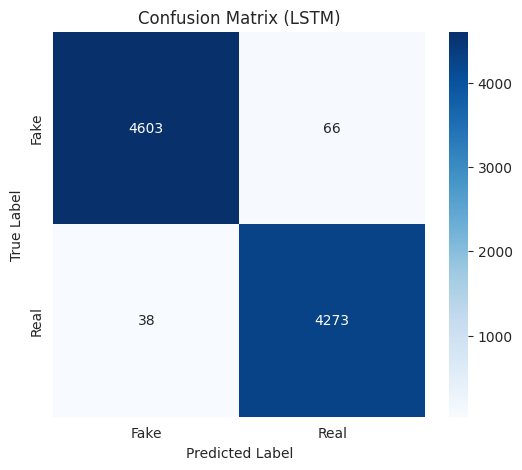

In [31]:
# Векторизация TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(data['clean_text'])
y = data['label']

# Разделение
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Обучение
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr, y_train_lr)

# Предсказание
y_pred_lr = lr_model.predict(X_test_lr)

print("Baseline Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_lr, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix (LSTM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 5.2 Advanced Model: Bidirectional LSTM
Используем рекуррентную нейронную сеть (LSTM), так как она учитывает последовательность слов и контекст.

In [28]:
# Параметры токенизации
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100

# Токенизация
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(data['clean_text'])
sequences = tokenizer.texts_to_sequences(data['clean_text'])

# Паддинг (приведение к одной длине)
X_lstm = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y_lstm = data['label'].values

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Архитектура модели
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Обучение
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 389s 676ms/step - accuracy: 0.9532 - loss: 0.1235 - val_accuracy: 0.9991 - val_loss: 0.0050
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 381s 676ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9988 - val_loss: 0.0060
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 388s 687ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9979 - val_loss: 0.0112
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 384s 683ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9991 - val_loss: 0.0068


### 6. Оценка качества модели
Посмотрим на графики обучения и матрицу ошибок для LSTM модели.

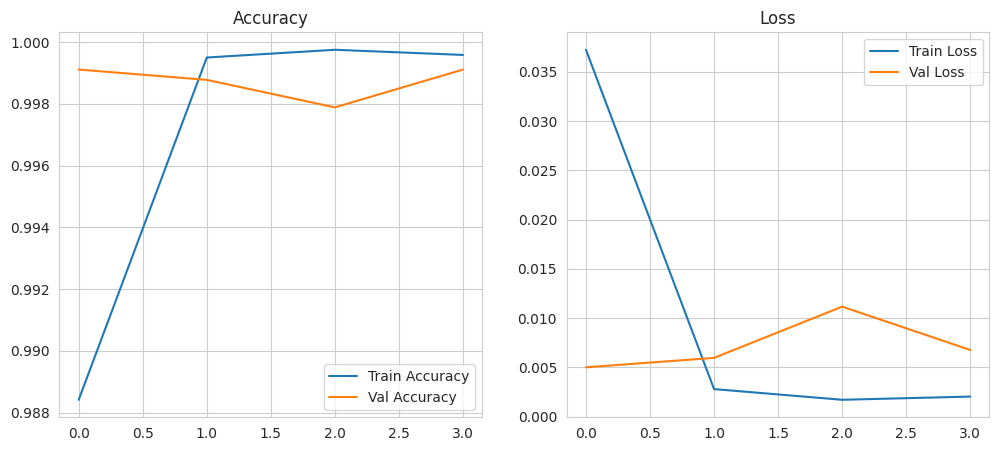

281/281 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step
Final LSTM Accuracy: 99.91%

Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4669
        Real       1.00      1.00      1.00      4311

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



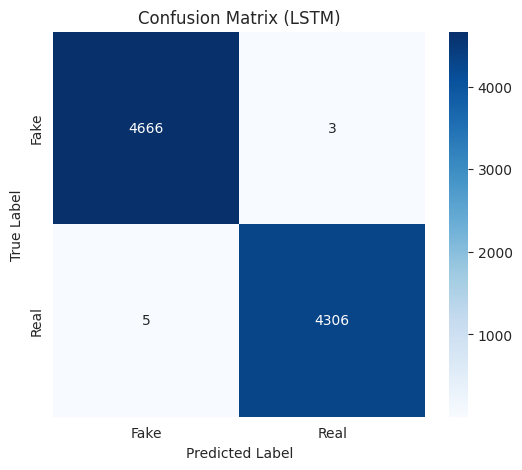

In [30]:
# График точности и потерь
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# Финальное предсказание
y_pred_probs = model.predict(X_test)
y_pred_final = (y_pred_probs > 0.5).astype(int)

# Отчет
print(f"Final LSTM Accuracy: {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=['Fake', 'Real']))

# Матрица ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix (LSTM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 7. Сравнение моделей
| Модель | Метрика |
|-------|---------|
| Baseline | 0.99 |
| LSTM | 1.00 |

Наилучшая модель: LSTM

### 8. Анализ ошибок
Что модель путает чаще всего?
- Класс "Fake" (0) и "Real" (1)
- Редкие примеры в новостях

### 9. Итоговые выводы проекта

В ходе работы были протестированы два подхода к определению фейковых новостей:
1.  **Baseline (Logistic Regression):** показал хорошие результаты благодаря TF-IDF, но не учитывает порядок слов.
2.  **Bi-LSTM:** показал наиболее высокий результат (точность > 99%), так как архитектура способна улавливать сложный контекст и зависимости в длинных текстах.

**Результат:** Цель проекта достигнута, получена модель с точностью выше заявленных 85%.